In [1]:
#--------ОСНОВНОЙ КОД НАЧИНАЕТСЯ ОТ СЮДА---------------
from bs4 import BeautifulSoup
import requests
import pandas as pd
import json

# URL и заголовки
url = "https://www.imdb.com/chart/top/"
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/101.0.4951.64 Safari/537.36 Edge/101.0.1210.53",
    'Accept-Language': 'en-us,en;q=0.5'
}

# Запрос
response = requests.get(url, headers=HEADERS)
soup = BeautifulSoup(response.content, "html.parser")

# Извлечение JSON
script_data = soup.find('script', {'type': "application/ld+json"}).text
data = json.loads(script_data)

# Инициализация списков для данных
movies = []
durations = []
ratings = []
link_ratings = []
links = []
genres = []
posters = []
votes = []
descriptions = []

# Извлечение данных из JSON
base_url = "https://www.imdb.com"
for item in data['itemListElement']:
    # Название
    movies.append(item['item']['name'])
    
    
    
    # Ссылка 
    link = item['item']['url']
    links.append(base_url + link if link.startswith("/") else link)
    
    # Рейтинг буква
    rating_label = item['item'].get('contentRating', None)
    link_ratings.append(rating_label if rating_label else "Unknown Rating")
    
    # Рейтинг число
    ratings.append(item['item'].get('aggregateRating', {}).get('ratingValue', 'Unknown Rating'))
    
    # Длительность 
    duration_raw = item['item'].get('duration', '')
    durations.append(duration_raw.replace("PT", "").replace("H", "h ").replace("M", "m").lower() if duration_raw else "Unknown Duration")
    
    # Жанр фильма
    genre_list = item['item'].get('genre', [])
    genres.append(", ".join(genre_list) if isinstance(genre_list, list) else genre_list)
    
    # Постер 
    image_data = item['item'].get('image', 'Unknown Poster')
    poster_url = image_data if isinstance(image_data, str) else image_data.get('url', 'Unknown Poster')
    posters.append(poster_url)
    
    # Количество голосов
    votes_count = item['item'].get('aggregateRating', {}).get('ratingCount', 'Unknown Votes')
    votes.append(votes_count)
    
    # Описание 
    description = item['item'].get('description', 'No Description Available')
    descriptions.append(description)

df = pd.DataFrame({
    "Title": movies,
    "Duration": durations,
    "Rating (Numeric)": ratings,
    "Rating (Label)": link_ratings,
    "Votes": votes,
    "Link": links,
    "Genres": genres,
    "Poster Link": posters,
    "Description": descriptions
})

print(df.head())  
df



                      Title Duration  Rating (Numeric) Rating (Label)  \
0  The Shawshank Redemption   2h 22m               9.3              R   
1             The Godfather   2h 55m               9.2              R   
2           The Dark Knight   2h 32m               9.0          PG-13   
3     The Godfather Part II   3h 22m               9.0              R   
4              12 Angry Men   1h 36m               9.0       Approved   

     Votes                                   Link                Genres  \
0  2985762  https://www.imdb.com/title/tt0111161/                 Drama   
1  2083696  https://www.imdb.com/title/tt0068646/          Crime, Drama   
2  2966157  https://www.imdb.com/title/tt0468569/  Action, Crime, Drama   
3  1405532  https://www.imdb.com/title/tt0071562/          Crime, Drama   
4   903085  https://www.imdb.com/title/tt0050083/          Crime, Drama   

                                         Poster Link  \
0  https://m.media-amazon.com/images/M/MV5BMDAyY2...  

,Title,Duration,Rating (Numeric),Rating (Label),Votes,Link,Genres,Poster Link,Description
0,The Shawshank Redemption,2h 22m,9.3,R,2985762,https://www.imdb.com/title/tt0111161/,Drama,https://m.media-amazon.com/images/M/MV5BMDAyY2...,A banker convicted of uxoricide forms a friend...
1,The Godfather,2h 55m,9.2,R,2083696,https://www.imdb.com/title/tt0068646/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BYTJkNG...,The aging patriarch of an organized crime dyna...
2,The Dark Knight,2h 32m,9.0,PG-13,2966157,https://www.imdb.com/title/tt0468569/,"Action, Crime, Drama",https://m.media-amazon.com/images/M/MV5BMTMxNT...,When a menace known as the Joker wreaks havoc ...
3,The Godfather Part II,3h 22m,9.0,R,1405532,https://www.imdb.com/title/tt0071562/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BNzc1OW...,The early life and career of Vito Corleone in ...
4,12 Angry Men,1h 36m,9.0,Approved,903085,https://www.imdb.com/title/tt0050083/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BYjE4Nz...,The jury in a New York City murder trial is fr...
...,...,...,...,...,...,...,...,...,...
245,Amores perros,2h 34m,8.0,R,258027,https://www.imdb.com/title/tt0245712/,"Drama, Thriller",https://m.media-amazon.com/images/M/MV5BMmUzND...,"An amateur dog fighter, a supermodel, and a de..."
246,The Help,2h 26m,8.1,PG-13,505681,https://www.imdb.com/title/tt1454029/,Drama,https://m.media-amazon.com/images/M/MV5BMTM5OT...,An aspiring author during the civil rights mov...
247,Rebecca,2h 10m,8.1,Approved,150797,https://www.imdb.com/title/tt0032976/,"Drama, Mystery, Romance",https://m.media-amazon.com/images/M/MV5BYTI0Mj...,A self-conscious woman juggles adjusting to he...
248,Koe no katachi,2h 10m,8.1,Not Rated,112206,https://www.imdb.com/title/tt5323662/,"Animation, Drama",https://m.media-amazon.com/images/M/MV5BOTFiNz...,"A deaf girl, Shoko, is bullied by the popular ..."


In [2]:
import pandas as pd
df = pd.DataFrame({
    "Title": movies,
    "Duration in minutes": durations,
    "Rating (Numeric)": ratings,
    "Rating (Label)": link_ratings,
    "Votes": votes,
    "Link": links,
    "Genres": genres,
    "Poster Link": posters,
    "Description": descriptions
})

# Преобразование продолжительности
def convert_duration(duration):
    if isinstance(duration, str):
        hours = 0
        minutes = 0
        if 'h' in duration:
            hours = int(duration.split('h')[0].strip())
            duration = duration.split('h')[1]
        # Извлекаем минуты
        if 'm' in duration:
            minutes = int(duration.split('m')[0].strip())
        total_minutes = hours * 60 + minutes
        return total_minutes
    return None

#Обновляем
df['Duration in minutes'] = df['Duration in minutes'].apply(convert_duration)

df.to_csv("IMDb_Top_250.csv", index=False)

print("Data saved to file IMDb_Top_250.csv")
df

Data saved to file IMDb_Top_250.csv


,Title,Duration in minutes,Rating (Numeric),Rating (Label),Votes,Link,Genres,Poster Link,Description
0,The Shawshank Redemption,142,9.3,R,2985762,https://www.imdb.com/title/tt0111161/,Drama,https://m.media-amazon.com/images/M/MV5BMDAyY2...,A banker convicted of uxoricide forms a friend...
1,The Godfather,175,9.2,R,2083696,https://www.imdb.com/title/tt0068646/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BYTJkNG...,The aging patriarch of an organized crime dyna...
2,The Dark Knight,152,9.0,PG-13,2966157,https://www.imdb.com/title/tt0468569/,"Action, Crime, Drama",https://m.media-amazon.com/images/M/MV5BMTMxNT...,When a menace known as the Joker wreaks havoc ...
3,The Godfather Part II,202,9.0,R,1405532,https://www.imdb.com/title/tt0071562/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BNzc1OW...,The early life and career of Vito Corleone in ...
4,12 Angry Men,96,9.0,Approved,903085,https://www.imdb.com/title/tt0050083/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BYjE4Nz...,The jury in a New York City murder trial is fr...
...,...,...,...,...,...,...,...,...,...
245,Amores perros,154,8.0,R,258027,https://www.imdb.com/title/tt0245712/,"Drama, Thriller",https://m.media-amazon.com/images/M/MV5BMmUzND...,"An amateur dog fighter, a supermodel, and a de..."
246,The Help,146,8.1,PG-13,505681,https://www.imdb.com/title/tt1454029/,Drama,https://m.media-amazon.com/images/M/MV5BMTM5OT...,An aspiring author during the civil rights mov...
247,Rebecca,130,8.1,Approved,150797,https://www.imdb.com/title/tt0032976/,"Drama, Mystery, Romance",https://m.media-amazon.com/images/M/MV5BYTI0Mj...,A self-conscious woman juggles adjusting to he...
248,Koe no katachi,130,8.1,Not Rated,112206,https://www.imdb.com/title/tt5323662/,"Animation, Drama",https://m.media-amazon.com/images/M/MV5BOTFiNz...,"A deaf girl, Shoko, is bullied by the popular ..."


In [3]:
# Новый df
df_1 = df.copy() 


print("Пропущенные значения:\n", df_1.isnull().sum())

df_1['Rating (Numeric)'] = pd.to_numeric(df_1['Rating (Numeric)'], errors='coerce') 
df_1['Rating (Numeric)'].fillna(df_1['Rating (Numeric)'].mean(), inplace=True)  
df_1.dropna(subset=['Title'], inplace=True)  

#Нормализация числовых данных
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_1['Votes'] = scaler.fit_transform(df_1[['Votes']]) 
df_1['Duration in minutes'] = scaler.fit_transform(df_1[['Duration in minutes']])  

#One-hot Encoding 
genre_encoded = df_1['Genres'].str.get_dummies(sep=", ")  # Преобразуем жанры в формат one-hot encoding
df_1 = pd.concat([df_1, genre_encoded], axis=1)  # Добавляем закодированные жанры в DataFrame

df_1.drop_duplicates(inplace=True)

df_1.to_csv("IMDb_Top_250_Cleaned.csv", index=False)
print(" Cleaned data saved to IMDb_Top_250_Cleaned.csv")
df_1
    

Пропущенные значения:
 Title                  0
Duration in minutes    0
Rating (Numeric)       0
Rating (Label)         0
Votes                  0
Link                   0
Genres                 0
Poster Link            0
Description            0
dtype: int64


C:\Users\Асылхан\AppData\Local\Temp\ipykernel_15576\4015589866.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_1['Rating (Numeric)'].fillna(df_1['Rating (Numeric)'].mean(), inplace=True)


 Cleaned data saved to IMDb_Top_250_Cleaned.csv


,Title,Duration in minutes,Rating (Numeric),Rating (Label),Votes,Link,Genres,Poster Link,Description,Action,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,The Shawshank Redemption,0.502591,9.3,R,1.000000,https://www.imdb.com/title/tt0111161/,Drama,https://m.media-amazon.com/images/M/MV5BMDAyY2...,A banker convicted of uxoricide forms a friend...,0,...,0,0,0,0,0,0,0,0,0,0
1,The Godfather,0.673575,9.2,R,0.695092,https://www.imdb.com/title/tt0068646/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BYTJkNG...,The aging patriarch of an organized crime dyna...,0,...,0,0,0,0,0,0,0,0,0,0
2,The Dark Knight,0.554404,9.0,PG-13,0.993373,https://www.imdb.com/title/tt0468569/,"Action, Crime, Drama",https://m.media-amazon.com/images/M/MV5BMTMxNT...,When a menace known as the Joker wreaks havoc ...,1,...,0,0,0,0,0,0,0,0,0,0
3,The Godfather Part II,0.813472,9.0,R,0.465865,https://www.imdb.com/title/tt0071562/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BNzc1OW...,The early life and career of Vito Corleone in ...,0,...,0,0,0,0,0,0,0,0,0,0
4,12 Angry Men,0.264249,9.0,Approved,0.296033,https://www.imdb.com/title/tt0050083/,"Crime, Drama",https://m.media-amazon.com/images/M/MV5BYjE4Nz...,The jury in a New York City murder trial is fr...,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Amores perros,0.564767,8.0,R,0.077996,https://www.imdb.com/title/tt0245712/,"Drama, Thriller",https://m.media-amazon.com/images/M/MV5BMmUzND...,"An amateur dog fighter, a supermodel, and a de...",0,...,0,0,0,0,0,0,0,1,0,0
246,The Help,0.523316,8.1,PG-13,0.161706,https://www.imdb.com/title/tt1454029/,Drama,https://m.media-amazon.com/images/M/MV5BMTM5OT...,An aspiring author during the civil rights mov...,0,...,0,0,0,0,0,0,0,0,0,0
247,Rebecca,0.440415,8.1,Approved,0.041751,https://www.imdb.com/title/tt0032976/,"Drama, Mystery, Romance",https://m.media-amazon.com/images/M/MV5BYTI0Mj...,A self-conscious woman juggles adjusting to he...,0,...,0,0,0,1,1,0,0,0,0,0
248,Koe no katachi,0.440415,8.1,Not Rated,0.028707,https://www.imdb.com/title/tt5323662/,"Animation, Drama",https://m.media-amazon.com/images/M/MV5BOTFiNz...,"A deaf girl, Shoko, is bullied by the popular ...",0,...,0,0,0,0,0,0,0,0,0,0


Average rating: 8.3096
Median Rating: 8.2
Rating Distribution:
 count    250.000000
mean       8.309600
std        0.234023
min        8.000000
25%        8.100000
50%        8.200000
75%        8.400000
max        9.300000
Name: Rating (Numeric), dtype: float64


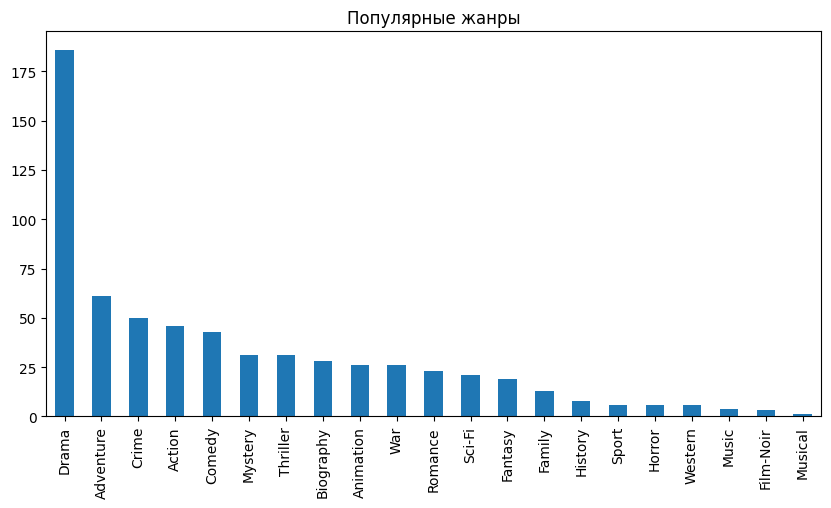

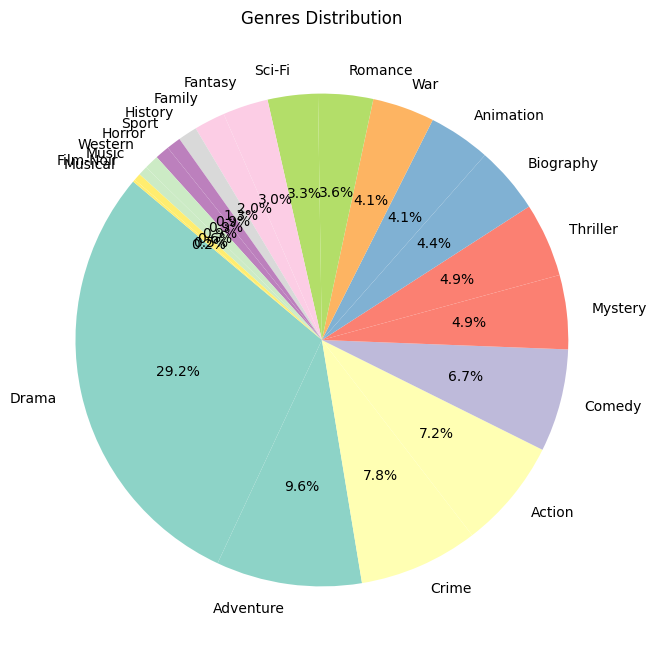

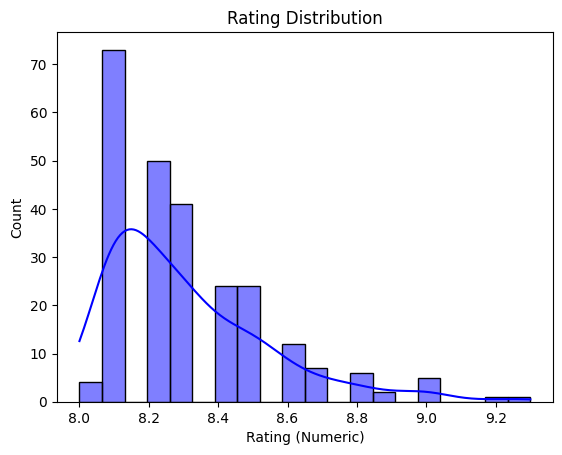

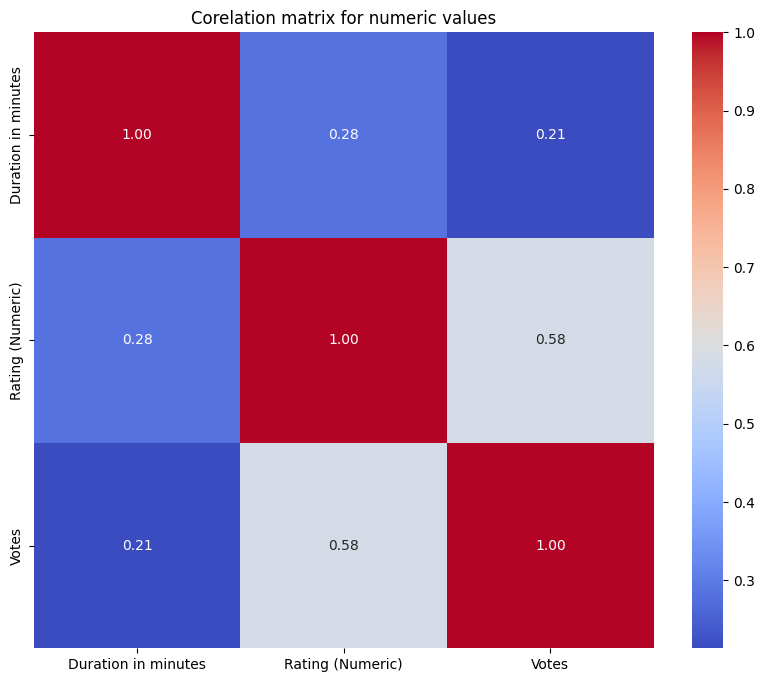

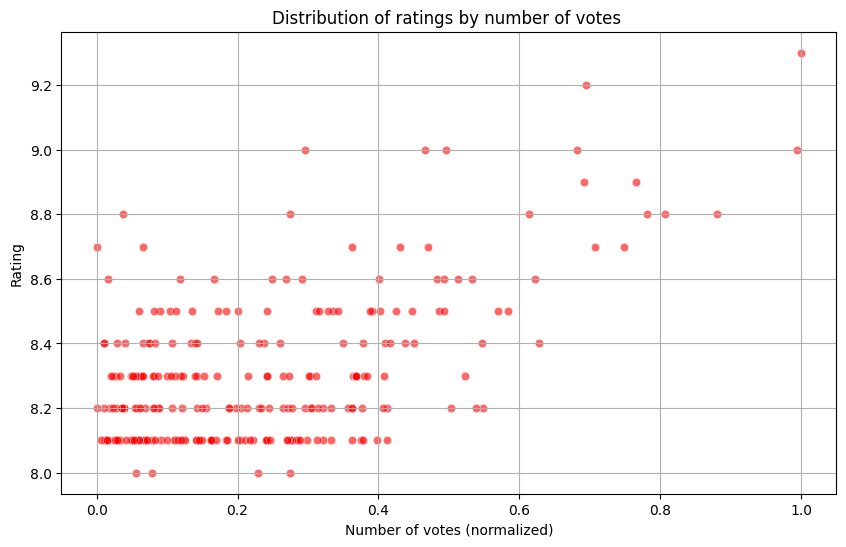

C:\Users\Асылхан\AppData\Local\Temp\ipykernel_15576\433306719.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=expanded_df, x='Genres_List', y='Rating (Numeric)', inner='quartile', palette='muted')


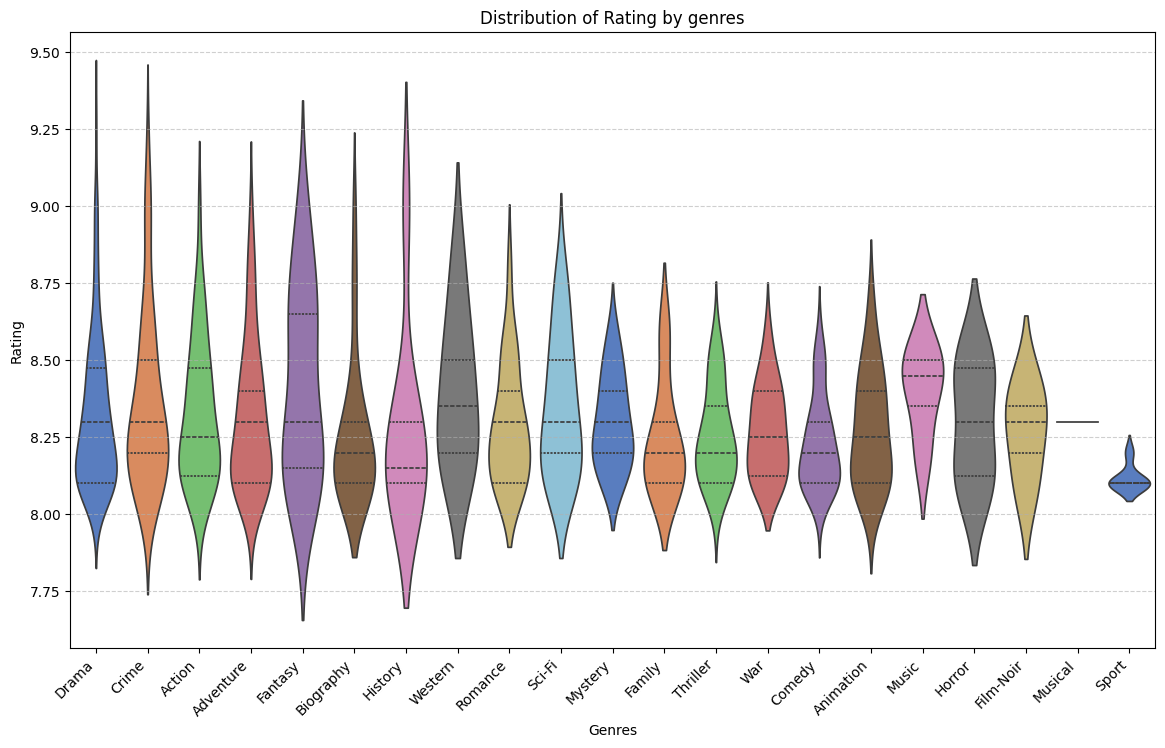

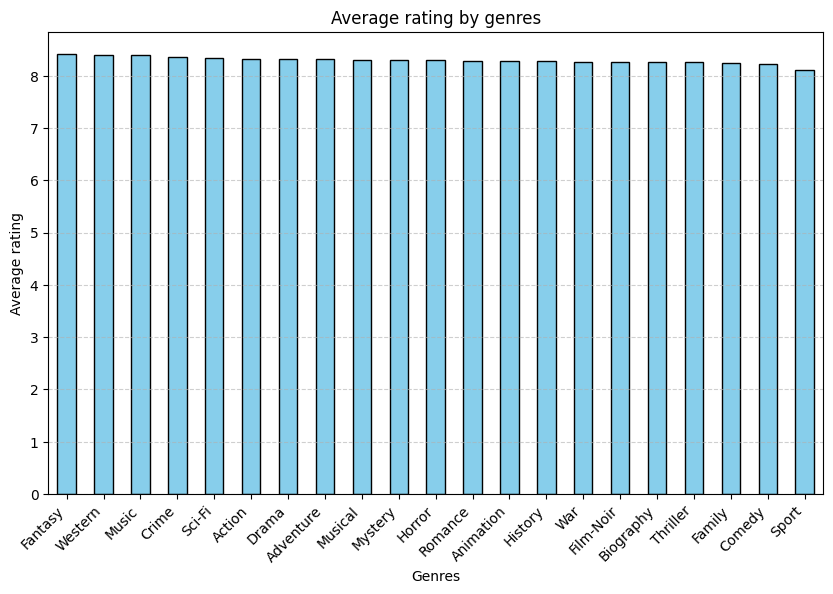

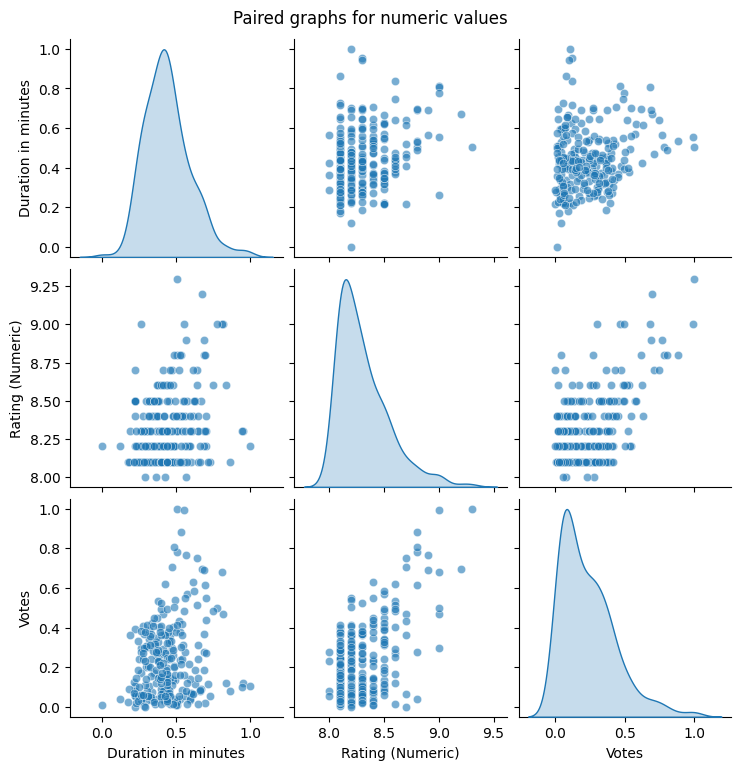

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Average rating:", df_1['Rating (Numeric)'].mean())
print("Median Rating:", df_1['Rating (Numeric)'].median())
print("Rating Distribution:\n", df_1['Rating (Numeric)'].describe())

# Визуализация данных
# Популярные жанры
genre_counts = genre_encoded.sum().sort_values(ascending=False)
genre_counts.plot(kind='bar', figsize=(10, 5), title='Популярные жанры')
plt.show()

#Круговая(жанры)
plt.figure(figsize=(10, 8))
genre_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='Set3')
plt.title('Genres Distribution')
plt.ylabel('')  
plt.show()

# Распределение рейтингов
sns.histplot(df['Rating (Numeric)'], kde=True, bins=20, color='blue')
plt.title('Rating Distribution')
plt.show()


numeric_columns = df_1[["Duration in minutes", "Rating (Numeric)", "Votes"]]

# Построение корреляционной матрицы
correlation_matrix = numeric_columns.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Corelation matrix for numeric values')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_1, x='Votes', y='Rating (Numeric)', alpha=0.6, color = 'red')
plt.title('Distribution of ratings by number of votes ')
plt.xlabel('Number of votes (normalized)')
plt.ylabel('Rating')
plt.grid(True)
plt.show()

# Разделение жанров для каждого фильма
expanded_df = df.copy()
expanded_df['Genres_List'] = expanded_df['Genres'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
expanded_df = expanded_df.explode('Genres_List')  # Разделяем каждый жанр в отдельную строку

# Violin plot
plt.figure(figsize=(14, 8))
sns.violinplot(data=expanded_df, x='Genres_List', y='Rating (Numeric)', inner='quartile', palette='muted')
plt.title('Distribution of Rating by genres')
plt.xlabel('Genres')
plt.ylabel('Rating')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Средний рейтинг по жанрам
avg_rating_by_genre = expanded_df.groupby('Genres_List')['Rating (Numeric)'].mean().sort_values(ascending=False)
avg_rating_by_genre.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Average rating by genres')
plt.xlabel('Genres')
plt.ylabel('Average rating')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Скатер для числовых значений
sns.pairplot(numeric_columns, diag_kind='kde', kind='scatter', plot_kws={'alpha': 0.6})
plt.suptitle('Paired graphs for numeric values', y=1.02)
plt.show()


MAE: 0.15724830487973313
MSE: 0.04026759641250957
R²: 0.29230937763603615


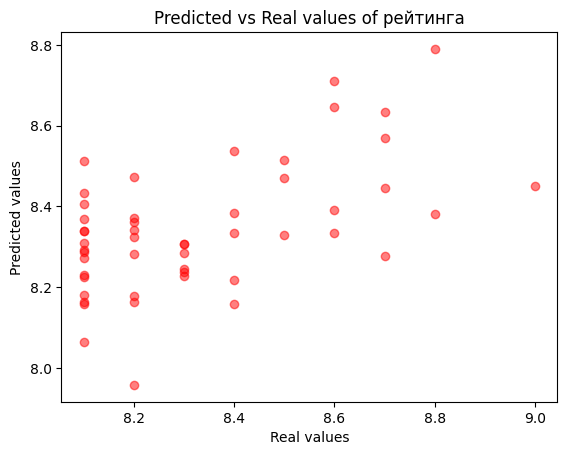

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

features = ['Votes','Duration in minutes'] + list(genre_encoded.columns)
X = df_1[features]
y = df_1['Rating (Numeric)']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred,))
print("R²:", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred, alpha=0.5, color = 'red')
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Real values of рейтинга")
plt.show()


In [6]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

df = pd.read_csv("IMDb_Top_250.csv")  

# One-hot encoding
df['Genres_List'] = df['Genres'].apply(lambda x: [genre.strip() for genre in x.split(',') if isinstance(x, str)])
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['Genres_List'])

# косинусное сходство
genre_similarity = cosine_similarity(genres_encoded, genres_encoded)

# Функция для рекомендаций на основе жанров
def recommend_movies_by_genres(movie_title, num_recommendations=5):
    if movie_title not in df['Title'].values:
        return "The movie was not found in the dataset. Check the title or try a different movie"
    
    # Индекс выбранного фильма
    idx = df[df['Title'] == movie_title].index[0]
    
    # Сходство фильмов по жанрам
    sim_scores = list(enumerate(genre_similarity[idx]))
    
    # Сортировка по сходству
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # 5 рекомендаций (исключая сам фильм)
    sim_scores = [score for score in sim_scores if score[0] != idx][:num_recommendations]
    movie_indices = [i[0] for i in sim_scores]
    
    # Возврат рекомендуемых фильмов с информацией о ссылках
    return df.iloc[movie_indices][['Title', 'Genres', 'Rating (Numeric)', 'Rating (Label)', 'Duration in minutes', 'Description', 'Link']]


user_movie = input("Enter the name of a movie you liked: ")
recommendations = recommend_movies_by_genres(user_movie, num_recommendations=5)

# Вывод рекомендаций
if isinstance(recommendations, str):
    print(recommendations)  # Вывод ошибки
else:
    print(f"The movie you liked: {user_movie}\n")
    print("We recommend the following movies:\n")
    for _, rec in recommendations.iterrows():
        print(f"Название: {rec['Title']}")
        print(f"Жанры: {rec['Genres']}")
        print(f"Rating: {rec['Rating (Numeric)']}")
        print(f"Rating (Label): {rec['Rating (Label)']}")
        print(f"Duration: {rec['Duration in minutes']} minutes")
        print(f"Description: {rec['Description']}")
        print(f"Link: {rec['Link']}\n")
        print("-" * 40)


The movie you liked: Se7en

We recommend the following movies:

Название: The Usual Suspects
Жанры: Crime, Drama, Mystery
Rating: 8.5
Rating (Label): R
Duration: 106 minutes
Description: The sole survivor of a pier shoot-out tells the story of how a notorious criminal influenced the events that began with five criminals meeting in a seemingly random police lineup.
Link: https://www.imdb.com/title/tt0114814/

----------------------------------------
Название: Witness for the Prosecution
Жанры: Crime, Drama, Mystery
Rating: 8.4
Rating (Label): Approved
Duration: 116 minutes
Description: A veteran British barrister must defend his client in a murder trial that has surprise after surprise.
Link: https://www.imdb.com/title/tt0051201/

----------------------------------------
Название: Tengoku to jigoku
Жанры: Crime, Drama, Mystery
Rating: 8.4
Rating (Label): Not Rated
Duration: 143 minutes
Description: An executive of a Yokohama shoe company becomes a victim of extortion when his chauffeur&